In [ ]:
# ============================================================
# ConViTx - Potato Disease Classification
# PAPER-STYLE ARCHITECTURE
#
# CNN + SE  ───────┐
#                  ├── Feature Fusion → Classifier
# ViT + SE  ───────┘
#
# NO CAAF
# NO CROSS-ATTENTION
# NO ADAPTIVE FEATURE FUSION
# ============================================================

import os
import zipfile
import numpy as np
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers


# ============================================================
# 1. CONFIGURATION
# ============================================================

ZIP_PATH = "/content/Potato.zip"
EXTRACT_DIR = "/content/Potato"

IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 10

INITIAL_LR = 1e-4
SEED = 42

AUTOTUNE = tf.data.AUTOTUNE


# ============================================================
# 2. EXTRACT POTATO DATASET
# ============================================================

if not os.path.exists(EXTRACT_DIR):

    print("Extracting Potato.zip...")

    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)

    print("Extraction completed.")

else:

    print("Dataset already extracted.")


# ============================================================
# 3. FIND ACTUAL DATASET DIRECTORY
# ============================================================

def find_dataset_directory(root):

    candidates = []

    for current_root, dirs, files in os.walk(root):

        image_dirs = 0

        for d in dirs:

            folder = os.path.join(current_root, d)

            try:

                image_files = [
                    f for f in os.listdir(folder)
                    if f.lower().endswith(
                        (
                            ".jpg",
                            ".jpeg",
                            ".png",
                            ".bmp"
                        )
                    )
                ]

                if len(image_files) > 0:
                    image_dirs += 1

            except Exception:
                pass

        if image_dirs >= 3:
            candidates.append(current_root)

    if len(candidates) == 0:
        return root

    # Select the deepest valid directory
    candidates.sort(
        key=lambda x: x.count(os.sep),
        reverse=True
    )

    return candidates[0]


DATASET_DIR = find_dataset_directory(
    EXTRACT_DIR
)

print("\nDataset directory:")
print(DATASET_DIR)


# ============================================================
# 4. LOAD DATASET
# ============================================================

train_ds = tf.keras.utils.image_dataset_from_directory(

    DATASET_DIR,

    validation_split=0.20,

    subset="training",

    seed=SEED,

    image_size=(
        IMG_SIZE,
        IMG_SIZE
    ),

    batch_size=BATCH_SIZE,

    label_mode="categorical",

    shuffle=True
)


val_ds = tf.keras.utils.image_dataset_from_directory(

    DATASET_DIR,

    validation_split=0.20,

    subset="validation",

    seed=SEED,

    image_size=(
        IMG_SIZE,
        IMG_SIZE
    ),

    batch_size=BATCH_SIZE,

    label_mode="categorical",

    shuffle=False
)


# ============================================================
# 5. CLASS INFORMATION
# ============================================================

CLASS_NAMES = train_ds.class_names

NUM_CLASSES = len(CLASS_NAMES)

print("\nClasses:")
for i, name in enumerate(CLASS_NAMES):
    print(i, ":", name)

print("\nNumber of classes:", NUM_CLASSES)


# ============================================================
# 6. PREFETCH
# ============================================================

train_ds = train_ds.prefetch(
    AUTOTUNE
)

val_ds = val_ds.prefetch(
    AUTOTUNE
)


# ============================================================
# 7. DATA AUGMENTATION
# ============================================================

augmentation = keras.Sequential(

    [

        layers.RandomFlip(
            "horizontal"
        ),

        layers.RandomRotation(
            0.10
        ),

        layers.RandomZoom(
            0.10
        ),

        layers.RandomContrast(
            0.10
        )

    ],

    name="augmentation"
)


# ============================================================
# 8. SE BLOCK
# ============================================================

class SEBlock(layers.Layer):

    def __init__(
        self,
        reduction=16,
        **kwargs
    ):

        super().__init__(**kwargs)

        self.reduction = reduction

    def build(self, input_shape):

        channels = int(
            input_shape[-1]
        )

        reduced_channels = max(
            channels // self.reduction,
            1
        )

        self.global_pool = (
            layers.GlobalAveragePooling2D()
        )

        self.fc1 = layers.Dense(
            reduced_channels,
            activation="relu"
        )

        self.fc2 = layers.Dense(
            channels,
            activation="sigmoid"
        )

        self.reshape = layers.Reshape(
            (1, 1, channels)
        )

        super().build(input_shape)

    def call(self, inputs):

        se = self.global_pool(
            inputs
        )

        se = self.fc1(se)

        se = self.fc2(se)

        se = self.reshape(se)

        return inputs * se


# ============================================================
# 9. CNN BRANCH
# ============================================================

cnn_input = keras.Input(

    shape=(
        IMG_SIZE,
        IMG_SIZE,
        3
    ),

    name="image"
)


cnn_x = augmentation(
    cnn_input
)


cnn_x = (
    tf.keras.applications
    .mobilenet_v2
    .preprocess_input(
        cnn_x
    )
)


# ============================================================
# MobileNetV2
# ============================================================

cnn_backbone = (

    tf.keras.applications
    .MobileNetV2(

        input_shape=(
            IMG_SIZE,
            IMG_SIZE,
            3
        ),

        include_top=False,

        weights="imagenet"
    )

)


# Fine-tuning strategy

cnn_backbone.trainable = True

for layer in cnn_backbone.layers[:-30]:

    layer.trainable = False


cnn_x = cnn_backbone(
    cnn_x
)


# ============================================================
# CNN PROJECTION
# ============================================================

cnn_x = layers.Conv2D(

    256,

    kernel_size=1,

    padding="same",

    use_bias=False,

    name="cnn_projection"

)(cnn_x)


cnn_x = layers.BatchNormalization()(
    cnn_x
)


cnn_x = layers.Activation(
    "relu"
)(cnn_x)


# ============================================================
# CNN SE
# ============================================================

cnn_x = SEBlock(

    reduction=16,

    name="cnn_se"

)(cnn_x)


# ============================================================
# GLOBAL CNN FEATURE
# ============================================================

cnn_feature = (
    layers.GlobalAveragePooling2D(
        name="cnn_global_pool"
    )(cnn_x)
)


cnn_feature = layers.Dense(

    256,

    activation="relu",

    name="cnn_feature"

)(cnn_feature)


# ============================================================
# 10. VISION TRANSFORMER PATCH LAYER
# ============================================================

class Patches(layers.Layer):

    def __init__(
        self,
        patch_size=16,
        **kwargs
    ):

        super().__init__(**kwargs)

        self.patch_size = patch_size

    def call(self, images):

        batch_size = tf.shape(
            images
        )[0]

        patches = tf.image.extract_patches(

            images=images,

            sizes=[
                1,
                self.patch_size,
                self.patch_size,
                1
            ],

            strides=[
                1,
                self.patch_size,
                self.patch_size,
                1
            ],

            rates=[
                1,
                1,
                1,
                1
            ],

            padding="VALID"
        )

        patch_dims = (
            patches.shape[-1]
        )

        patches = tf.reshape(

            patches,

            [
                batch_size,
                -1,
                patch_dims
            ]

        )

        return patches


# ============================================================
# 11. PATCH ENCODER
# ============================================================

class PatchEncoder(layers.Layer):

    def __init__(
        self,
        num_patches,
        projection_dim,
        **kwargs
    ):

        super().__init__(**kwargs)

        self.num_patches = (
            num_patches
        )

        self.projection = (
            layers.Dense(
                projection_dim
            )
        )

        self.position_embedding = (
            layers.Embedding(
                input_dim=num_patches,
                output_dim=projection_dim
            )
        )

    def call(self, patches):

        positions = tf.range(

            start=0,

            limit=self.num_patches,

            delta=1

        )

        projected = (
            self.projection(
                patches
            )
        )

        encoded = (
            projected
            +
            self.position_embedding(
                positions
            )
        )

        return encoded


# ============================================================
# 12. ViT BRANCH
# ============================================================

vit_x = augmentation(
    cnn_input
)


# ============================================================
# PATCH EXTRACTION
# ============================================================

patches = Patches(

    patch_size=16,

    name="patches"

)(vit_x)


# 224 / 16 = 14
# 14 × 14 = 196 patches

vit_x = PatchEncoder(

    num_patches=196,

    projection_dim=256,

    name="patch_encoder"

)(patches)


# ============================================================
# 13. TRANSFORMER ENCODER
# ============================================================

for i in range(4):

    # ----------------------------------------
    # Layer Normalization
    # ----------------------------------------

    x1 = layers.LayerNormalization(

        epsilon=1e-6,

        name=f"vit_norm1_{i}"

    )(vit_x)


    # ----------------------------------------
    # Multi-Head Self Attention
    # ----------------------------------------

    attention_output = (

        layers.MultiHeadAttention(

            num_heads=8,

            key_dim=32,

            dropout=0.1,

            name=f"vit_attention_{i}"

        )(

            x1,

            x1

        )

    )


    # ----------------------------------------
    # Residual
    # ----------------------------------------

    x2 = layers.Add(

        name=f"vit_residual1_{i}"

    )([

        vit_x,

        attention_output

    ])


    # ----------------------------------------
    # Feed Forward Network
    # ----------------------------------------

    x3 = layers.LayerNormalization(

        epsilon=1e-6,

        name=f"vit_norm2_{i}"

    )(x2)


    x3 = layers.Dense(

        512,

        activation=tf.nn.gelu,

        name=f"vit_ffn1_{i}"

    )(x3)


    x3 = layers.Dropout(
        0.1
    )(x3)


    x3 = layers.Dense(

        256,

        name=f"vit_ffn2_{i}"

    )(x3)


    # ----------------------------------------
    # Residual
    # ----------------------------------------

    vit_x = layers.Add(

        name=f"vit_residual2_{i}"

    )([

        x2,

        x3

    ])


# ============================================================
# 14. ViT NORMALIZATION
# ============================================================

vit_x = layers.LayerNormalization(

    epsilon=1e-6,

    name="vit_final_norm"

)(vit_x)


# ============================================================
# ViT → FEATURE MAP
# ============================================================

# 196 tokens → 14 × 14 feature map

vit_x = layers.Reshape(

    (
        14,
        14,
        256
    ),

    name="vit_feature_map"

)(vit_x)


# ============================================================
# 15. ViT SE BLOCK
# ============================================================

vit_x = SEBlock(

    reduction=16,

    name="vit_se"

)(vit_x)


# ============================================================
# 16. GLOBAL ViT FEATURE
# ============================================================

vit_feature = (

    layers.GlobalAveragePooling2D(

        name="vit_global_pool"

    )(vit_x)

)


vit_feature = layers.Dense(

    256,

    activation="relu",

    name="vit_feature"

)(vit_feature)


# ============================================================
# 17. CNN + ViT FEATURE FUSION
# ============================================================
#
# IMPORTANT:
# This is simple feature concatenation.
#
# NO:
# - CAAF
# - Cross Attention
# - Adaptive Feature Fusion
#
# ============================================================

fused_features = layers.Concatenate(

    name="feature_fusion"

)([

    cnn_feature,

    vit_feature

])


# ============================================================
# 18. CLASSIFIER
# ============================================================

x = layers.Dense(

    512,

    activation="relu",

    name="fusion_dense"

)(fused_features)


x = layers.BatchNormalization()(
    x
)


x = layers.Dropout(

    0.4

)(x)


x = layers.Dense(

    256,

    activation="relu",

    name="classifier_dense"

)(x)


x = layers.Dropout(

    0.3

)(x)


output = layers.Dense(

    NUM_CLASSES,

    activation="softmax",

    name="output"

)(x)


# ============================================================
# 19. FINAL ConViTx MODEL
# ============================================================

model = keras.Model(

    inputs=cnn_input,

    outputs=output,

    name="ConViTx_Potato"

)


# ============================================================
# 20. MODEL SUMMARY
# ============================================================

model.summary()


# ============================================================
# 21. COMPILE
# ============================================================

model.compile(

    optimizer=keras.optimizers.Adam(

        learning_rate=INITIAL_LR

    ),

    loss=keras.losses.CategoricalCrossentropy(

        label_smoothing=0.1

    ),

    metrics=[

        "accuracy",

        keras.metrics.Precision(
            name="precision"
        ),

        keras.metrics.Recall(
            name="recall"
        )

    ]

)


# ============================================================
# 22. LEARNING RATE SCHEDULER
# ============================================================

def lr_schedule(epoch, lr):

    if epoch < 10:

        return 1e-4

    elif epoch < 20:

        return 5e-5

    elif epoch < 35:

        return 2e-5

    else:

        return 1e-5


lr_callback = (
    keras.callbacks
    .LearningRateScheduler(

        lr_schedule,

        verbose=1

    )
)


# ============================================================
# 23. EARLY STOPPING
# ============================================================

early_stopping = (

    keras.callbacks.EarlyStopping(

        monitor="val_accuracy",

        patience=8,

        mode="max",

        restore_best_weights=True,

        verbose=1

    )

)


# ============================================================
# 24. CHECKPOINT
# ============================================================

checkpoint = (

    keras.callbacks.ModelCheckpoint(

        "/content/ConViTx_Potato_best.keras",

        monitor="val_accuracy",

        mode="max",

        save_best_only=True,

        verbose=1

    )

)


# ============================================================
# 25. TRAIN
# ============================================================

history = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=EPOCHS,

    callbacks=[

        lr_callback,

        early_stopping,

        checkpoint

    ]

)


# ============================================================
# 26. FINAL EVALUATION
# ============================================================

print("\n")
print("=" * 60)
print("FINAL ConViTx POTATO RESULTS")
print("=" * 60)


results = model.evaluate(

    val_ds,

    verbose=1

)


for name, value in zip(

    model.metrics_names,

    results

):

    print(
        f"{name}: {value:.4f}"
    )


# ============================================================
# 27. SAVE FINAL MODEL
# ============================================================

model.save(

    "/content/ConViTx_Potato.keras"

)


print("\nModel saved to:")

print(
    "/content/ConViTx_Potato.keras"
)

Extracting Potato.zip...
Extraction completed.

Dataset directory:
/content/Potato/Potato
Found 2152 files belonging to 3 classes.
Using 1722 files for training.
Found 2152 files belonging to 3 classes.
Using 430 files for validation.

Classes:
0 : Potato___Early_blight
1 : Potato___Late_blight
2 : Potato___healthy

Number of classes: 3


Model: "ConViTx_Potato"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 224, 224,  │          0 │ image[0][0],      │
│ (Sequential)        │ 3)                │            │ image[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patches (Patches)   │ (None, None, 768) │          0 │ augmentation[1][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder       │ (None, 196, 256)  │    247,040 │ patches[0][0]     │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vit_norm1_0         │ (None, 196, 256)  │        512 │ patch_encoder[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vit_attention_0     │ (None, 196, 256)  │    263,168 │ vit_norm1_0[0][0… │
│ (MultiHeadAttentio… │                   │            │ vit_norm1_0[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vit_residual1_0     │ (None, 196, 256)  │          0 │ patch_encoder[0]… │
│ (Add)               │                   │            │ vit_attention_0[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vit_norm2_0         │ (None, 196, 256)  │        512 │ vit_residual1_0[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vit_ffn1_0 (Dense)  │ (None, 196, 512)  │    131,584 │ vit_norm2_0[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_18          │ (None, 196, 512)  │          0 │ vit_ffn1_0[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vit_ffn2_0 (Dense)  │ (None, 196, 256)  │    131,328 │ dropout_18[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vit_residual2_0     │ (None, 196, 256)  │          0 │ vit_residual1_0[… │
│ (Add)               │                   │            │ vit_ffn2_0[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vit_norm1_1         │ (None, 196, 256)  │        512 │ vit_residual2_0[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vit_attention_1     │ (None, 196, 256)  │    263,168 │ vit_norm1_1[0][0… │
│ (MultiHeadAttentio… │                   │            │ vit_norm1_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vit_residual1_1     │ (None, 196, 256)  │          0 │ vit_residual2_0[… │
│ (Add)               │                   │            │ vit_attention_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vit_norm2_1         │ (None, 196, 256)  │        512 │ vit_residual1_1[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vit_ffn1_1 (Dense)  │ (None, 196, 512)  │    131,584 │ vit_norm2_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_20          │ (None, 196, 512)  │          0 │ vit_ffn1_1[0][0]  │
│ (Dropout)           │                   │            │                 

 Total params: 5,487,971 (20.93 MB)

 Trainable params: 4,754,851 (18.14 MB)

 Non-trainable params: 733,120 (2.80 MB)


Epoch 1: LearningRateScheduler setting learning rate to 0.0001.
Epoch 1/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.5822 - loss: 0.9699 - precision: 0.6219 - recall: 0.5334
Epoch 1: val_accuracy improved from None to 0.88140, saving model to /content/ConViTx_Potato_best.keras

Epoch 1: finished saving model to /content/ConViTx_Potato_best.keras
108/108 ━━━━━━━━━━━━━━━━━━━━ 45s 171ms/step - accuracy: 0.7793 - loss: 0.6901 - precision: 0.8224 - recall: 0.7474 - val_accuracy: 0.8814 - val_loss: 0.8238 - val_precision: 1.0000 - val_recall: 0.3023 - learning_rate: 1.0000e-04

Epoch 2: LearningRateScheduler setting learning rate to 0.0001.
Epoch 2/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.9225 - loss: 0.4768 - precision: 0.9403 - recall: 0.9029
Epoch 2: val_accuracy did not improve from 0.88140
108/108 ━━━━━━━━━━━━━━━━━━━━ 13s 124ms/step - accuracy: 0.9344 - loss: 0.4542 - precision: 0.9502 - recall: 0.9204 - val_accuracy: 0.7721 - val_loss: 0.6697 - val_pr

In [ ]:
# ============================================================
# ConViTx + CAAF
# Potato Disease Classification
#
# Architecture:
#
#                 ┌── CNN (MobileNetV2) ── SE ──┐
# Input ──────────┤                              ├─ CAAF ── Classifier
#                 └── ViT ──────────────── SE ──┘
#
# CAAF = Cross-Attention Adaptive Feature Fusion
#
# NO separate Adaptive Feature Fusion
# CAAF is the only fusion mechanism
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import os
import zipfile
import numpy as np
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers


# ============================================================
# 2. CONFIGURATION
# ============================================================

ZIP_PATH = "/content/Potato.zip"
EXTRACT_DIR = "/content/Potato"

IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 10

INITIAL_LR = 1e-4
SEED = 42

AUTOTUNE = tf.data.AUTOTUNE


# ============================================================
# 3. EXTRACT POTATO DATASET
# ============================================================

if not os.path.exists(EXTRACT_DIR):

    print("Extracting Potato.zip...")

    with zipfile.ZipFile(
        ZIP_PATH,
        "r"
    ) as zip_ref:

        zip_ref.extractall(
            EXTRACT_DIR
        )

    print("Extraction completed.")

else:

    print("Dataset already extracted.")


# ============================================================
# 4. FIND DATASET DIRECTORY
# ============================================================

def find_dataset_directory(root):

    candidates = []

    for current_root, dirs, files in os.walk(root):

        image_dirs = 0

        for d in dirs:

            folder = os.path.join(
                current_root,
                d
            )

            try:

                image_files = [
                    f
                    for f in os.listdir(folder)
                    if f.lower().endswith(
                        (
                            ".jpg",
                            ".jpeg",
                            ".png",
                            ".bmp"
                        )
                    )
                ]

                if len(image_files) > 0:
                    image_dirs += 1

            except Exception:
                pass

        if image_dirs >= 3:
            candidates.append(
                current_root
            )

    if len(candidates) == 0:
        return root

    candidates.sort(
        key=lambda x: x.count(os.sep),
        reverse=True
    )

    return candidates[0]


DATASET_DIR = find_dataset_directory(
    EXTRACT_DIR
)

print("\nDataset directory:")
print(DATASET_DIR)


# ============================================================
# 5. LOAD DATASET
# ============================================================

train_ds = tf.keras.utils.image_dataset_from_directory(

    DATASET_DIR,

    validation_split=0.20,

    subset="training",

    seed=SEED,

    image_size=(
        IMG_SIZE,
        IMG_SIZE
    ),

    batch_size=BATCH_SIZE,

    label_mode="categorical",

    shuffle=True
)


val_ds = tf.keras.utils.image_dataset_from_directory(

    DATASET_DIR,

    validation_split=0.20,

    subset="validation",

    seed=SEED,

    image_size=(
        IMG_SIZE,
        IMG_SIZE
    ),

    batch_size=BATCH_SIZE,

    label_mode="categorical",

    shuffle=False
)


# ============================================================
# 6. CLASS INFORMATION
# ============================================================

CLASS_NAMES = train_ds.class_names

NUM_CLASSES = len(
    CLASS_NAMES
)

print("\nClasses:")

for i, name in enumerate(
    CLASS_NAMES
):

    print(
        f"{i}: {name}"
    )

print(
    "\nNumber of classes:",
    NUM_CLASSES
)


# ============================================================
# 7. PREFETCH
# ============================================================

train_ds = train_ds.prefetch(
    AUTOTUNE
)

val_ds = val_ds.prefetch(
    AUTOTUNE
)


# ============================================================
# 8. DATA AUGMENTATION
# ============================================================

augmentation = keras.Sequential(

    [

        layers.RandomFlip(
            "horizontal"
        ),

        layers.RandomRotation(
            0.10
        ),

        layers.RandomZoom(
            0.10
        ),

        layers.RandomContrast(
            0.10
        )

    ],

    name="augmentation"
)


# ============================================================
# 9. SE BLOCK
# ============================================================

class SEBlock(layers.Layer):

    def __init__(
        self,
        reduction=16,
        **kwargs
    ):

        super().__init__(
            **kwargs
        )

        self.reduction = reduction


    def build(
        self,
        input_shape
    ):

        channels = int(
            input_shape[-1]
        )

        reduced_channels = max(
            channels // self.reduction,
            1
        )

        self.global_pool = (
            layers.GlobalAveragePooling2D()
        )

        self.fc1 = layers.Dense(
            reduced_channels,
            activation="relu"
        )

        self.fc2 = layers.Dense(
            channels,
            activation="sigmoid"
        )

        self.reshape = layers.Reshape(
            (1, 1, channels)
        )

        super().build(
            input_shape
        )


    def call(
        self,
        inputs
    ):

        se = self.global_pool(
            inputs
        )

        se = self.fc1(
            se
        )

        se = self.fc2(
            se
        )

        se = self.reshape(
            se
        )

        return inputs * se


# ============================================================
# 10. INPUT
# ============================================================

image_input = keras.Input(

    shape=(
        IMG_SIZE,
        IMG_SIZE,
        3
    ),

    name="image"
)


# ============================================================
# 11. CNN BRANCH
# MobileNetV2 + SE
# ============================================================

cnn_x = augmentation(
    image_input
)


cnn_x = (
    tf.keras.applications
    .mobilenet_v2
    .preprocess_input(
        cnn_x
    )
)


# ============================================================
# MobileNetV2 BACKBONE
# ============================================================

cnn_backbone = (

    tf.keras.applications
    .MobileNetV2(

        input_shape=(
            IMG_SIZE,
            IMG_SIZE,
            3
        ),

        include_top=False,

        weights="imagenet"
    )
)


# ============================================================
# FINE-TUNING
# ============================================================

cnn_backbone.trainable = True

for layer in cnn_backbone.layers[:-30]:

    layer.trainable = False


cnn_x = cnn_backbone(
    cnn_x
)


# ============================================================
# CNN PROJECTION
# ============================================================

cnn_x = layers.Conv2D(

    256,

    kernel_size=1,

    padding="same",

    use_bias=False,

    name="cnn_projection"

)(cnn_x)


cnn_x = layers.BatchNormalization()(
    cnn_x
)


cnn_x = layers.Activation(
    "relu"
)(cnn_x)


# ============================================================
# CNN SE
# ============================================================

cnn_x = SEBlock(

    reduction=16,

    name="cnn_se"

)(cnn_x)


# ============================================================
# CNN GLOBAL FEATURE
# ============================================================

cnn_feature = (

    layers.GlobalAveragePooling2D(

        name="cnn_global_pool"

    )(cnn_x)

)


cnn_feature = layers.Dense(

    256,

    activation="relu",

    name="cnn_feature"

)(cnn_feature)


# ============================================================
# 12. PATCH EXTRACTION
# ============================================================

class Patches(
    layers.Layer
):

    def __init__(
        self,
        patch_size=16,
        **kwargs
    ):

        super().__init__(
            **kwargs
        )

        self.patch_size = patch_size


    def call(
        self,
        images
    ):

        batch_size = tf.shape(
            images
        )[0]

        patches = tf.image.extract_patches(

            images=images,

            sizes=[
                1,
                self.patch_size,
                self.patch_size,
                1
            ],

            strides=[
                1,
                self.patch_size,
                self.patch_size,
                1
            ],

            rates=[
                1,
                1,
                1,
                1
            ],

            padding="VALID"

        )

        patch_dims = (
            patches.shape[-1]
        )

        patches = tf.reshape(

            patches,

            [
                batch_size,
                -1,
                patch_dims
            ]

        )

        return patches


# ============================================================
# 13. PATCH ENCODER
# ============================================================

class PatchEncoder(
    layers.Layer
):

    def __init__(
        self,
        num_patches,
        projection_dim,
        **kwargs
    ):

        super().__init__(
            **kwargs
        )

        self.num_patches = (
            num_patches
        )

        self.projection = (
            layers.Dense(
                projection_dim
            )
        )

        self.position_embedding = (
            layers.Embedding(

                input_dim=num_patches,

                output_dim=projection_dim

            )
        )


    def call(
        self,
        patches
    ):

        positions = tf.range(

            start=0,

            limit=self.num_patches,

            delta=1

        )

        projected = (
            self.projection(
                patches
            )
        )

        encoded = (

            projected

            +

            self.position_embedding(
                positions
            )

        )

        return encoded


# ============================================================
# 14. ViT BRANCH
# ============================================================

vit_x = augmentation(
    image_input
)


# ============================================================
# PATCHES
# ============================================================

patches = Patches(

    patch_size=16,

    name="patches"

)(vit_x)


# 224 / 16 = 14
# 14 × 14 = 196 patches

vit_x = PatchEncoder(

    num_patches=196,

    projection_dim=256,

    name="patch_encoder"

)(patches)


# ============================================================
# 15. TRANSFORMER ENCODER BLOCKS
# ============================================================

for i in range(4):


    # --------------------------------------------------------
    # Layer Normalization
    # --------------------------------------------------------

    x1 = layers.LayerNormalization(

        epsilon=1e-6,

        name=f"vit_norm1_{i}"

    )(vit_x)


    # --------------------------------------------------------
    # Multi-Head Self Attention
    # --------------------------------------------------------

    attention_output = (

        layers.MultiHeadAttention(

            num_heads=8,

            key_dim=32,

            dropout=0.1,

            name=f"vit_attention_{i}"

        )(

            x1,

            x1

        )

    )


    # --------------------------------------------------------
    # Residual connection
    # --------------------------------------------------------

    x2 = layers.Add(

        name=f"vit_residual1_{i}"

    )([

        vit_x,

        attention_output

    ])


    # --------------------------------------------------------
    # Feed Forward Network
    # --------------------------------------------------------

    x3 = layers.LayerNormalization(

        epsilon=1e-6,

        name=f"vit_norm2_{i}"

    )(x2)


    x3 = layers.Dense(

        512,

        activation=tf.nn.gelu,

        name=f"vit_ffn1_{i}"

    )(x3)


    x3 = layers.Dropout(
        0.1
    )(x3)


    x3 = layers.Dense(

        256,

        name=f"vit_ffn2_{i}"

    )(x3)


    # --------------------------------------------------------
    # Residual
    # --------------------------------------------------------

    vit_x = layers.Add(

        name=f"vit_residual2_{i}"

    )([

        x2,

        x3

    ])


# ============================================================
# 16. FINAL ViT NORMALIZATION
# ============================================================

vit_x = layers.LayerNormalization(

    epsilon=1e-6,

    name="vit_final_norm"

)(vit_x)


# ============================================================
# 17. CONVERT ViT TOKENS TO FEATURE MAP
# ============================================================

vit_x = layers.Reshape(

    (
        14,
        14,
        256
    ),

    name="vit_feature_map"

)(vit_x)


# ============================================================
# 18. ViT SE
# ============================================================

vit_x = SEBlock(

    reduction=16,

    name="vit_se"

)(vit_x)


# ============================================================
# 19. ViT GLOBAL FEATURE
# ============================================================

vit_feature = (

    layers.GlobalAveragePooling2D(

        name="vit_global_pool"

    )(vit_x)

)


vit_feature = layers.Dense(

    256,

    activation="relu",

    name="vit_feature"

)(vit_feature)


# ============================================================
# 20. CAAF
# Cross-Attention Adaptive Feature Fusion
# ============================================================

class CrossAttentionAdaptiveFeatureFusion(
    layers.Layer
):

    def __init__(

        self,

        projection_dim=256,

        num_heads=8,

        dropout=0.1,

        **kwargs

    ):

        super().__init__(
            **kwargs
        )

        self.projection_dim = (
            projection_dim
        )


        # ----------------------------------------------------
        # Normalization
        # ----------------------------------------------------

        self.cnn_norm = (
            layers.LayerNormalization(
                epsilon=1e-6
            )
        )

        self.vit_norm = (
            layers.LayerNormalization(
                epsilon=1e-6
            )
        )


        # ----------------------------------------------------
        # CNN → ViT attention
        # ----------------------------------------------------

        self.cnn_to_vit = (

            layers.MultiHeadAttention(

                num_heads=num_heads,

                key_dim=(
                    projection_dim
                    // num_heads
                ),

                dropout=dropout,

                name="cnn_to_vit_attention"

            )

        )


        # ----------------------------------------------------
        # ViT → CNN attention
        # ----------------------------------------------------

        self.vit_to_cnn = (

            layers.MultiHeadAttention(

                num_heads=num_heads,

                key_dim=(
                    projection_dim
                    // num_heads
                ),

                dropout=dropout,

                name="vit_to_cnn_attention"

            )

        )


        # ----------------------------------------------------
        # Adaptive gate
        # ----------------------------------------------------

        self.gate_dense1 = layers.Dense(

            projection_dim,

            activation="relu"

        )


        self.gate_dense2 = layers.Dense(

            2,

            activation="softmax"

        )


        # ----------------------------------------------------
        # Output projection
        # ----------------------------------------------------

        self.output_projection = (
            layers.Dense(
                projection_dim,
                activation="relu"
            )
        )


    def call(

        self,

        inputs

    ):

        cnn_feature, vit_feature = (
            inputs
        )


        # ----------------------------------------------------
        # Convert feature vectors to tokens
        # ----------------------------------------------------

        cnn_tokens = tf.expand_dims(

            cnn_feature,

            axis=1

        )


        vit_tokens = tf.expand_dims(

            vit_feature,

            axis=1

        )


        # ----------------------------------------------------
        # Normalize
        # ----------------------------------------------------

        cnn_norm = self.cnn_norm(
            cnn_tokens
        )

        vit_norm = self.vit_norm(
            vit_tokens
        )


        # ----------------------------------------------------
        # CNN → ViT Cross Attention
        # ----------------------------------------------------

        cnn_attention = (

            self.cnn_to_vit(

                query=cnn_norm,

                key=vit_norm,

                value=vit_norm

            )

        )


        cnn_fused = (

            cnn_tokens

            +

            cnn_attention

        )


        # ----------------------------------------------------
        # ViT → CNN Cross Attention
        # ----------------------------------------------------

        vit_attention = (

            self.vit_to_cnn(

                query=vit_norm,

                key=cnn_norm,

                value=cnn_norm

            )

        )


        vit_fused = (

            vit_tokens

            +

            vit_attention

        )


        # ----------------------------------------------------
        # Remove sequence dimension
        # ----------------------------------------------------

        cnn_fused = tf.squeeze(

            cnn_fused,

            axis=1

        )


        vit_fused = tf.squeeze(

            vit_fused,

            axis=1

        )


        # ----------------------------------------------------
        # Adaptive gating
        # ----------------------------------------------------

        gate_input = tf.concat(

            [

                cnn_fused,

                vit_fused

            ],

            axis=-1

        )


        gate = self.gate_dense1(

            gate_input

        )


        gate = self.gate_dense2(

            gate

        )


        cnn_weight = gate[
            :,
            0:1
        ]


        vit_weight = gate[
            :,
            1:2
        ]


        # ----------------------------------------------------
        # Adaptive weighted fusion
        # ----------------------------------------------------

        fused = (

            cnn_weight
            * cnn_fused

            +

            vit_weight
            * vit_fused

        )


        # ----------------------------------------------------
        # Final projection
        # ----------------------------------------------------

        fused = self.output_projection(
            fused
        )


        return fused


# ============================================================
# APPLY CAAF
# ============================================================

fused_features = (

    CrossAttentionAdaptiveFeatureFusion(

        projection_dim=256,

        num_heads=8,

        dropout=0.1,

        name="CAAF"

    )([

        cnn_feature,

        vit_feature

    ])

)


# ============================================================
# 21. CLASSIFICATION HEAD
# ============================================================

x = layers.Dense(

    512,

    activation="relu",

    name="fusion_dense"

)(fused_features)


x = layers.BatchNormalization()(
    x
)


x = layers.Dropout(

    0.4

)(x)


x = layers.Dense(

    256,

    activation="relu",

    name="classifier_dense"

)(x)


x = layers.Dropout(

    0.3

)(x)


output = layers.Dense(

    NUM_CLASSES,

    activation="softmax",

    name="output"

)(x)


# ============================================================
# 22. FINAL ConViTx MODEL
# ============================================================

model = keras.Model(

    inputs=image_input,

    outputs=output,

    name="ConViTx_CAAF_Potato"

)


# ============================================================
# 23. MODEL SUMMARY
# ============================================================

model.summary()


# ============================================================
# 24. COMPILE
# ============================================================

model.compile(

    optimizer=keras.optimizers.Adam(

        learning_rate=INITIAL_LR

    ),

    loss=keras.losses.CategoricalCrossentropy(

        label_smoothing=0.1

    ),

    metrics=[

        "accuracy",

        keras.metrics.Precision(
            name="precision"
        ),

        keras.metrics.Recall(
            name="recall"
        )

    ]

)


# ============================================================
# 25. LEARNING RATE SCHEDULER
# ============================================================

def lr_schedule(
    epoch,
    lr
):

    if epoch < 10:

        return 1e-4

    elif epoch < 20:

        return 5e-5

    elif epoch < 35:

        return 2e-5

    else:

        return 1e-5


lr_callback = (

    keras.callbacks
    .LearningRateScheduler(

        lr_schedule,

        verbose=1

    )

)


# ============================================================
# 26. EARLY STOPPING
# ============================================================

early_stopping = (

    keras.callbacks.EarlyStopping(

        monitor="val_accuracy",

        patience=8,

        mode="max",

        restore_best_weights=True,

        verbose=1

    )

)


# ============================================================
# 27. MODEL CHECKPOINT
# ============================================================

checkpoint = (

    keras.callbacks.ModelCheckpoint(

        "/content/ConViTx_CAAF_Potato_best.keras",

        monitor="val_accuracy",

        mode="max",

        save_best_only=True,

        verbose=1

    )

)


# ============================================================
# 28. TRAIN
# ============================================================

print("\n")
print("=" * 60)
print("STARTING ConViTx + CAAF TRAINING")
print("=" * 60)

print(
    "Classes:",
    CLASS_NAMES
)

print(
    "Number of classes:",
    NUM_CLASSES
)

print(
    "Image size:",
    IMG_SIZE
)

print(
    "Batch size:",
    BATCH_SIZE
)

print(
    "Epochs:",
    EPOCHS
)

print(
    "Learning rate:",
    INITIAL_LR
)

print("=" * 60)


history = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=EPOCHS,

    callbacks=[

        lr_callback,

        early_stopping,

        checkpoint

    ]

)


# ============================================================
# 29. FINAL EVALUATION
# ============================================================

print("\n")
print("=" * 60)
print("FINAL ConViTx + CAAF RESULTS")
print("=" * 60)


results = model.evaluate(

    val_ds,

    verbose=1

)


for name, value in zip(

    model.metrics_names,

    results

):

    print(
        f"{name}: {value:.4f}"
    )


# ============================================================
# 30. SAVE FINAL MODEL
# ============================================================

FINAL_MODEL_PATH = (
    "/content/ConViTx_CAAF_Potato.keras"
)


model.save(
    FINAL_MODEL_PATH
)


print("\n")
print("=" * 60)
print("MODEL SAVED")
print("=" * 60)

print(
    FINAL_MODEL_PATH
)

Dataset already extracted.

Dataset directory:
/content/Potato/Potato
Found 2152 files belonging to 3 classes.
Using 1722 files for training.
Found 2152 files belonging to 3 classes.
Using 430 files for validation.

Classes:
0: Potato___Early_blight
1: Potato___Late_blight
2: Potato___healthy

Number of classes: 3


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


Model: "ConViTx_CAAF_Potato"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 224, 224,  │          0 │ image[0][0],      │
│ (Sequential)        │ 3)                │            │ image[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patches (Patches)   │ (None, None, 768) │          0 │ augmentation[1][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder       │ (None, 196, 256)  │    247,040 │ patches[0][0]     │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vit_norm1_0         │ (None, 196, 256)  │        512 │ patch_encoder[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vit_attention_0     │ (None, 196, 256)  │    263,168 │ vit_norm1_0[0][0… │
│ (MultiHeadAttentio… │                   │            │ vit_norm1_0[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vit_residual1_0     │ (None, 196, 256)  │          0 │ patch_encoder[0]… │
│ (Add)               │                   │            │ vit_attention_0[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vit_norm2_0         │ (None, 196, 256)  │        512 │ vit_residual1_0[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vit_ffn1_0 (Dense)  │ (None, 196, 512)  │    131,584 │ vit_norm2_0[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_28          │ (None, 196, 512)  │          0 │ vit_ffn1_0[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vit_ffn2_0 (Dense)  │ (None, 196, 256)  │    131,328 │ dropout_28[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vit_residual2_0     │ (None, 196, 256)  │          0 │ vit_residual1_0[… │
│ (Add)               │                   │            │ vit_ffn2_0[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vit_norm1_1         │ (None, 196, 256)  │        512 │ vit_residual2_0[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vit_attention_1     │ (None, 196, 256)  │    263,168 │ vit_norm1_1[0][0… │
│ (MultiHeadAttentio… │                   │            │ vit_norm1_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vit_residual1_1     │ (None, 196, 256)  │          0 │ vit_residual2_0[… │
│ (Add)               │                   │            │ vit_attention_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vit_norm2_1         │ (None, 196, 256)  │        512 │ vit_residual1_1[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vit_ffn1_1 (Dense)  │ (None, 196, 512)  │    131,584 │ vit_norm2_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_30          │ (None, 196, 512)  │          0 │ vit_ffn1_1[0][0]  │
│ (Dropout)           │                   │            │                 

 Total params: 6,081,893 (23.20 MB)

 Trainable params: 5,348,773 (20.40 MB)

 Non-trainable params: 733,120 (2.80 MB)



STARTING ConViTx + CAAF TRAINING
Classes: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
Number of classes: 3
Image size: 224
Batch size: 16
Epochs: 10
Learning rate: 0.0001

Epoch 1: LearningRateScheduler setting learning rate to 0.0001.
Epoch 1/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.7459 - loss: 0.7401 - precision: 0.7973 - recall: 0.6572
Epoch 1: val_accuracy improved from None to 0.64651, saving model to /content/ConViTx_CAAF_Potato_best.keras

Epoch 1: finished saving model to /content/ConViTx_CAAF_Potato_best.keras
108/108 ━━━━━━━━━━━━━━━━━━━━ 49s 168ms/step - accuracy: 0.8513 - loss: 0.5835 - precision: 0.8904 - recall: 0.8020 - val_accuracy: 0.6465 - val_loss: 0.8820 - val_precision: 1.0000 - val_recall: 0.3047 - learning_rate: 1.0000e-04

Epoch 2: LearningRateScheduler setting learning rate to 0.0001.
Epoch 2/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.9352 - loss: 0.4568 - precision: 0.9456 - recall: 0.9266
Epoch 2

In [ ]:
# ============================================================
# COMPLETE CONFUSION MATRIX
# Shows ALL classes + ALL VALUES + %
# ============================================================

from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt


def complete_confusion_matrix(
    model,
    dataset,
    class_names,
    model_name
):

    # --------------------------------------------------------
    # GET TRUE + PREDICTED LABELS
    # --------------------------------------------------------

    y_true = []
    y_pred = []

    for images, labels in dataset:

        predictions = model.predict(
            images,
            verbose=0
        )

        true_labels = np.argmax(
            labels.numpy(),
            axis=1
        )

        predicted_labels = np.argmax(
            predictions,
            axis=1
        )

        y_true.extend(true_labels)
        y_pred.extend(predicted_labels)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)


    # --------------------------------------------------------
    # FORCE ALL CLASSES
    # --------------------------------------------------------

    num_classes = len(class_names)

    all_labels = np.arange(num_classes)

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=all_labels
    )


    # --------------------------------------------------------
    # PRINT RAW CONFUSION MATRIX
    # --------------------------------------------------------

    print("\n")
    print("=" * 70)
    print(model_name)
    print("=" * 70)

    print("\nRAW CONFUSION MATRIX:")
    print(cm)


    # --------------------------------------------------------
    # PRINT CLASS-WISE VALUES
    # --------------------------------------------------------

    print("\n")
    print("CLASS-WISE CONFUSION MATRIX")
    print("-" * 70)

    print(
        f"{'TRUE CLASS':30s}",
        end=""
    )

    for name in class_names:

        print(
            f"{name[:15]:>18s}",
            end=""
        )

    print()


    for i, name in enumerate(class_names):

        print(
            f"{name:30s}",
            end=""
        )

        for j in range(num_classes):

            print(
                f"{cm[i,j]:18d}",
                end=""
            )

        print()


    # --------------------------------------------------------
    # ROW-WISE PERCENTAGE
    # --------------------------------------------------------

    print("\n")
    print("ROW-WISE PERCENTAGE")
    print("-" * 70)

    row_totals = cm.sum(
        axis=1,
        keepdims=True
    )

    # Prevent division by zero
    row_totals_safe = np.where(
        row_totals == 0,
        1,
        row_totals
    )

    cm_percent = (
        cm /
        row_totals_safe
    ) * 100


    print(
        f"{'TRUE CLASS':30s}",
        end=""
    )

    for name in class_names:

        print(
            f"{name[:15]:>18s}",
            end=""
        )

    print()


    for i, name in enumerate(class_names):

        print(
            f"{name:30s}",
            end=""
        )

        for j in range(num_classes):

            print(
                f"{cm_percent[i,j]:17.2f}%",
                end=""
            )

        print()


    # --------------------------------------------------------
    # CLASSIFICATION REPORT
    # --------------------------------------------------------

    print("\n")
    print("CLASSIFICATION REPORT")
    print("-" * 70)

    print(
        classification_report(
            y_true,
            y_pred,
            labels=all_labels,
            target_names=class_names,
            digits=4,
            zero_division=0
        )
    )


    # --------------------------------------------------------
    # OVERALL ACCURACY
    # --------------------------------------------------------

    accuracy = (
        np.trace(cm)
        /
        np.sum(cm)
        if np.sum(cm) > 0
        else 0
    )

    print(
        f"Overall Accuracy: "
        f"{accuracy * 100:.2f}%"
    )


    # --------------------------------------------------------
    # PLOT WITH COUNT + PERCENTAGE
    # --------------------------------------------------------

    plt.figure(
        figsize=(9, 8)
    )

    plt.imshow(
        cm,
        interpolation="nearest"
    )

    plt.title(
        f"{model_name}\nConfusion Matrix"
    )

    plt.colorbar()


    ticks = np.arange(
        num_classes
    )

    plt.xticks(
        ticks,
        class_names,
        rotation=45,
        ha="right"
    )

    plt.yticks(
        ticks,
        class_names
    )


    # --------------------------------------------------------
    # SHOW BOTH COUNT AND %
    # --------------------------------------------------------

    for i in range(num_classes):

        for j in range(num_classes):

            text = (
                f"{cm[i,j]}\n"
                f"({cm_percent[i,j]:.1f}%)"
            )

            threshold = (
                cm.max() / 2
                if cm.max() > 0
                else 0
            )

            plt.text(
                j,
                i,
                text,
                ha="center",
                va="center",
                fontsize=11,
                color=(
                    "white"
                    if cm[i,j] > threshold
                    else "black"
                )
            )


    plt.xlabel(
        "Predicted Class"
    )

    plt.ylabel(
        "True Class"
    )

    plt.tight_layout()

    plt.show()


    return cm



ConViTx WITHOUT CAAF

RAW CONFUSION MATRIX:
[[  0   0   0]
 [  0 277   1]
 [  0   2 150]]


CLASS-WISE CONFUSION MATRIX
----------------------------------------------------------------------
TRUE CLASS                       Potato___Early_   Potato___Late_b   Potato___health
Potato___Early_blight                          0                 0                 0
Potato___Late_blight                           0               277                 1
Potato___healthy                               0                 2               150


ROW-WISE PERCENTAGE
----------------------------------------------------------------------
TRUE CLASS                       Potato___Early_   Potato___Late_b   Potato___health
Potato___Early_blight                      0.00%             0.00%             0.00%
Potato___Late_blight                       0.00%            99.64%             0.36%
Potato___healthy                           0.00%             1.32%            98.68%


CLASSIFICATION REPORT
----------

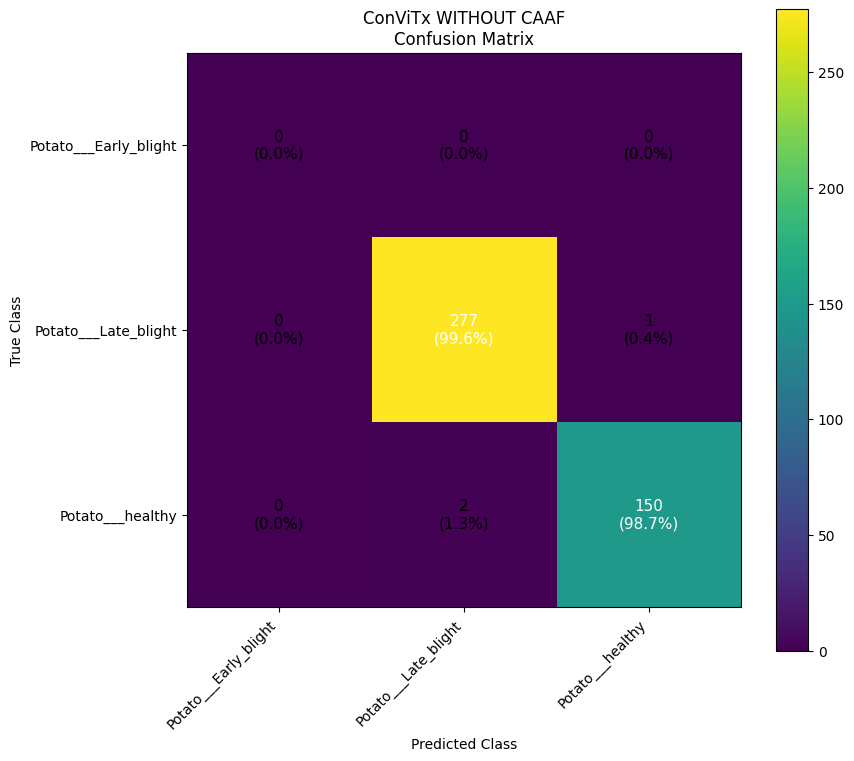

In [ ]:
cm_convitx = complete_confusion_matrix(
    model,
    val_ds,
    CLASS_NAMES,
    "ConViTx WITHOUT CAAF"
)



ConViTx + CAAF

RAW CONFUSION MATRIX:
[[  0   0   0]
 [  0 277   1]
 [  0   2 150]]


CLASS-WISE CONFUSION MATRIX
----------------------------------------------------------------------
TRUE CLASS                       Potato___Early_   Potato___Late_b   Potato___health
Potato___Early_blight                          0                 0                 0
Potato___Late_blight                           0               277                 1
Potato___healthy                               0                 2               150


ROW-WISE PERCENTAGE
----------------------------------------------------------------------
TRUE CLASS                       Potato___Early_   Potato___Late_b   Potato___health
Potato___Early_blight                      0.00%             0.00%             0.00%
Potato___Late_blight                       0.00%            99.64%             0.36%
Potato___healthy                           0.00%             1.32%            98.68%


CLASSIFICATION REPORT
----------------

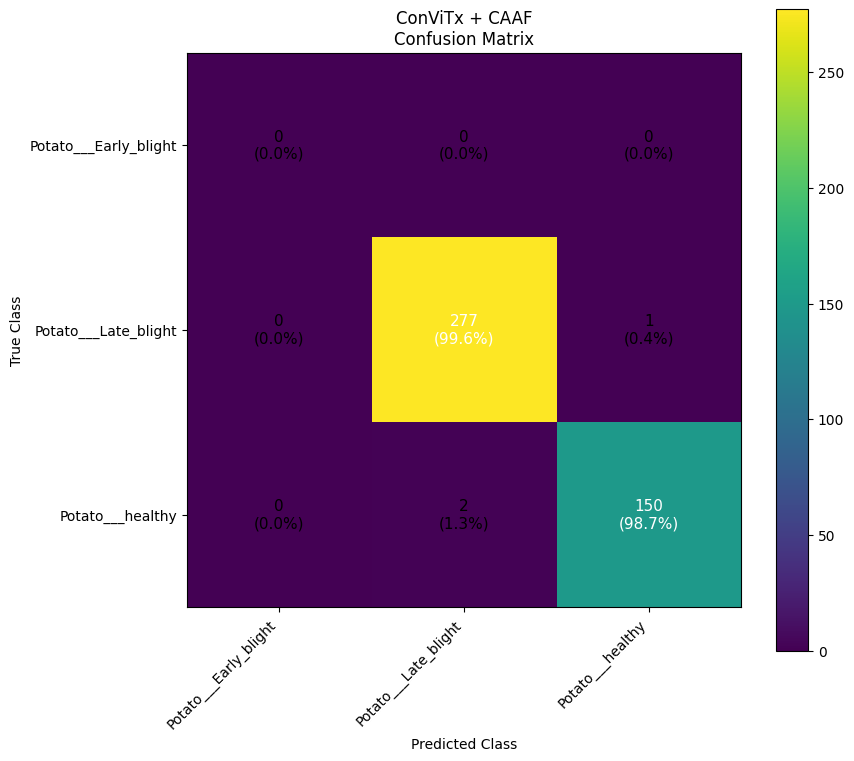

In [ ]:
cm_caaf = complete_confusion_matrix(
    model,
    val_ds,
    CLASS_NAMES,
    "ConViTx + CAAF"
)

Dataset already extracted.

Dataset directory:
/content/Potato/Potato
Potato___Early_blight: 1000 images
Potato___Late_blight: 1000 images
Potato___healthy: 152 images

Original dataset distribution:
Potato___Early_blight : 1000
Potato___Late_blight : 1000
Potato___healthy : 152

TRAIN DISTRIBUTION
Potato___Early_blight : 800
Potato___Late_blight : 800
Potato___healthy : 121

VALIDATION DISTRIBUTION
Potato___Early_blight : 200
Potato___Late_blight : 200
Potato___healthy : 31

✓ ALL THREE CLASSES ARE PRESENT IN VALIDATION SET


Model: "ConViTx_Potato"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 224, 224,  │          0 │ input[0][0],      │
│ (Sequential)        │ 3)                │            │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patches_1 (Patches) │ (None, None, 768) │          0 │ augmentation[1][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder_1     │ (None, 196, 256)  │    247,040 │ patches_1[0][0]   │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 256)  │        512 │ patch_encoder_1[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 196, 256)  │    263,168 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 196, 256)  │          0 │ patch_encoder_1[… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 256)  │        512 │ add_8[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_61 (Dense)    │ (None, 196, 512)  │    131,584 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_50          │ (None, 196, 512)  │          0 │ dense_61[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_62 (Dense)    │ (None, 196, 256)  │    131,328 │ dropout_50[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 196, 256)  │          0 │ add_8[0][0],      │
│                     │                   │            │ dense_62[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 256)  │        512 │ add_9[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 196, 256)  │    263,168 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, 196, 256)  │          0 │ add_9[0][0],      │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 256)  │        512 │ add_10[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_63 (Dense)    │ (None, 196, 512)  │    131,584 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_52          │ (None, 196, 512)  │          0 │ dense_63[0][0]    │
│ (Dropout)           │                   │            │                 

 Total params: 5,487,971 (20.93 MB)

 Trainable params: 4,754,851 (18.14 MB)

 Non-trainable params: 733,120 (2.80 MB)


STARTING ConViTx WITHOUT CAAF
Epoch 1/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.6614 - loss: 0.8578
Epoch 1: val_accuracy improved from None to 0.65429, saving model to /content/ConViTx_Potato_best.keras

Epoch 1: finished saving model to /content/ConViTx_Potato_best.keras
108/108 ━━━━━━━━━━━━━━━━━━━━ 54s 178ms/step - accuracy: 0.8199 - loss: 0.6302 - val_accuracy: 0.6543 - val_loss: 0.9555 - learning_rate: 1.0000e-04
Epoch 2/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.9389 - loss: 0.4533
Epoch 2: val_accuracy improved from 0.65429 to 0.87239, saving model to /content/ConViTx_Potato_best.keras

Epoch 2: finished saving model to /content/ConViTx_Potato_best.keras
108/108 ━━━━━━━━━━━━━━━━━━━━ 15s 136ms/step - accuracy: 0.9489 - loss: 0.4371 - val_accuracy: 0.8724 - val_loss: 0.7800 - learning_rate: 1.0000e-04
Epoch 3/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.9625 - loss: 0.4227
Epoch 3: val_accuracy improved from 0.87239 to 0.95128, sa

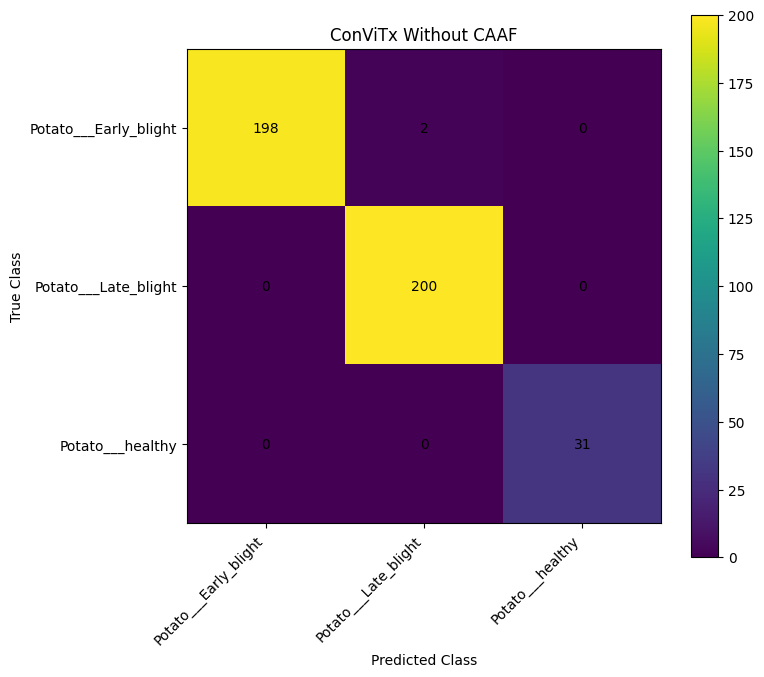


Saved:
/content/ConViTx_Potato.keras


In [ ]:
# ============================================================
# ConViTx - POTATO DISEASE CLASSIFICATION
# WITHOUT CAAF
#
# CNN (MobileNetV2) + SE
#              +
# ViT + SE
#              ↓
# Direct Concatenation
#              ↓
# Classifier
#
# 3 Potato classes
# Stratified 80:20 split
# Confusion Matrix
# Classification Report
# ============================================================

# ============================================================
# 1. IMPORTS
# ============================================================

import os
import zipfile
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

# ============================================================
# 2. CONFIGURATION
# ============================================================

ZIP_PATH = "/content/Potato.zip"
EXTRACT_DIR = "/content/Potato"

IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 10
SEED = 42

LEARNING_RATE = 1e-4

AUTOTUNE = tf.data.AUTOTUNE

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


# ============================================================
# 3. EXTRACT DATASET
# ============================================================

if not os.path.exists(EXTRACT_DIR):

    print("Extracting Potato.zip...")

    with zipfile.ZipFile(
        ZIP_PATH,
        "r"
    ) as zip_ref:

        zip_ref.extractall(
            EXTRACT_DIR
        )

    print("Extraction completed.")

else:

    print("Dataset already extracted.")


# ============================================================
# 4. FIND POTATO DATASET DIRECTORY
# ============================================================

REQUIRED_CLASSES = [
    "Potato___Early_blight",
    "Potato___Late_blight",
    "Potato___healthy"
]


def find_dataset_directory(root):

    for current_root, dirs, files in os.walk(root):

        if all(
            c in dirs
            for c in REQUIRED_CLASSES
        ):

            return current_root

    raise FileNotFoundError(
        "Could not find directory containing all "
        "three Potato classes."
    )


DATASET_DIR = find_dataset_directory(
    EXTRACT_DIR
)

print("\nDataset directory:")
print(DATASET_DIR)


# ============================================================
# 5. COLLECT ALL IMAGE PATHS
# ============================================================

image_paths = []
labels = []


for class_index, class_name in enumerate(
    REQUIRED_CLASSES
):

    class_dir = os.path.join(
        DATASET_DIR,
        class_name
    )

    if not os.path.exists(class_dir):

        raise FileNotFoundError(
            f"Missing class folder: {class_dir}"
        )


    class_images = [

        os.path.join(
            class_dir,
            f
        )

        for f in os.listdir(
            class_dir
        )

        if f.lower().endswith(
            (
                ".jpg",
                ".jpeg",
                ".png",
                ".bmp"
            )
        )

    ]


    print(
        f"{class_name}: "
        f"{len(class_images)} images"
    )


    image_paths.extend(
        class_images
    )

    labels.extend(
        [class_index] * len(class_images)
    )


image_paths = np.array(
    image_paths
)

labels = np.array(
    labels
)


# ============================================================
# 6. CHECK ORIGINAL DATASET
# ============================================================

print("\nOriginal dataset distribution:")

for i, class_name in enumerate(
    REQUIRED_CLASSES
):

    print(
        class_name,
        ":",
        np.sum(labels == i)
    )


if len(np.unique(labels)) != 3:

    raise ValueError(
        "All 3 Potato classes are not present."
    )


# ============================================================
# 7. STRATIFIED 80:20 SPLIT
# ============================================================

train_paths, val_paths, train_labels, val_labels = (

    train_test_split(

        image_paths,

        labels,

        test_size=0.20,

        random_state=SEED,

        stratify=labels

    )

)


# ============================================================
# 8. VERIFY SPLIT
# ============================================================

print("\n========================================")
print("TRAIN DISTRIBUTION")
print("========================================")

for i, class_name in enumerate(
    REQUIRED_CLASSES
):

    print(
        class_name,
        ":",
        np.sum(train_labels == i)
    )


print("\n========================================")
print("VALIDATION DISTRIBUTION")
print("========================================")

for i, class_name in enumerate(
    REQUIRED_CLASSES
):

    print(
        class_name,
        ":",
        np.sum(val_labels == i)
    )


# IMPORTANT CHECK
if np.any(
    np.bincount(
        val_labels,
        minlength=3
    ) == 0
):

    raise ValueError(
        "A class has zero validation images."
    )


print(
    "\n✓ ALL THREE CLASSES ARE PRESENT "
    "IN VALIDATION SET"
)


# ============================================================
# 9. TF.DATA LOADER
# ============================================================

def load_image(
    path,
    label
):

    image = tf.io.read_file(
        path
    )

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image = tf.image.resize(
        image,
        (
            IMG_SIZE,
            IMG_SIZE
        )
    )

    image = tf.cast(
        image,
        tf.float32
    )

    label = tf.one_hot(
        label,
        depth=3
    )

    return image, label


# ============================================================
# 10. DATASETS
# ============================================================

train_ds = tf.data.Dataset.from_tensor_slices(
    (
        train_paths,
        train_labels
    )
)

train_ds = train_ds.shuffle(
    len(train_paths),
    seed=SEED
)

train_ds = train_ds.map(
    load_image,
    num_parallel_calls=AUTOTUNE
)

train_ds = train_ds.batch(
    BATCH_SIZE
)

train_ds = train_ds.prefetch(
    AUTOTUNE
)


val_ds = tf.data.Dataset.from_tensor_slices(
    (
        val_paths,
        val_labels
    )
)

val_ds = val_ds.map(
    load_image,
    num_parallel_calls=AUTOTUNE
)

val_ds = val_ds.batch(
    BATCH_SIZE
)

val_ds = val_ds.prefetch(
    AUTOTUNE
)


CLASS_NAMES = REQUIRED_CLASSES
NUM_CLASSES = 3


# ============================================================
# 11. DATA AUGMENTATION
# ============================================================

augmentation = keras.Sequential(

    [

        layers.RandomFlip(
            "horizontal"
        ),

        layers.RandomRotation(
            0.10
        ),

        layers.RandomZoom(
            0.10
        ),

        layers.RandomContrast(
            0.10
        )

    ],

    name="augmentation"
)


# ============================================================
# 12. SE BLOCK
# ============================================================

class SEBlock(
    layers.Layer
):

    def __init__(
        self,
        reduction=16,
        **kwargs
    ):

        super().__init__(
            **kwargs
        )

        self.reduction = reduction


    def build(
        self,
        input_shape
    ):

        channels = int(
            input_shape[-1]
        )

        reduced = max(
            channels // self.reduction,
            1
        )

        self.pool = (
            layers.GlobalAveragePooling2D()
        )

        self.fc1 = layers.Dense(
            reduced,
            activation="relu"
        )

        self.fc2 = layers.Dense(
            channels,
            activation="sigmoid"
        )

        self.reshape = layers.Reshape(
            (
                1,
                1,
                channels
            )
        )

        super().build(
            input_shape
        )


    def call(
        self,
        inputs
    ):

        x = self.pool(
            inputs
        )

        x = self.fc1(
            x
        )

        x = self.fc2(
            x
        )

        x = self.reshape(
            x
        )

        return inputs * x


# ============================================================
# 13. INPUT
# ============================================================

inputs = keras.Input(

    shape=(
        IMG_SIZE,
        IMG_SIZE,
        3
    ),

    name="input"
)


# ============================================================
# 14. CNN BRANCH
# ============================================================

cnn_x = augmentation(
    inputs
)

cnn_x = (
    tf.keras.applications
    .mobilenet_v2
    .preprocess_input(
        cnn_x
    )
)


cnn_backbone = (
    tf.keras.applications
    .MobileNetV2(

        input_shape=(
            IMG_SIZE,
            IMG_SIZE,
            3
        ),

        include_top=False,

        weights="imagenet"

    )
)


cnn_backbone.trainable = True

for layer in cnn_backbone.layers[:-30]:

    layer.trainable = False


cnn_x = cnn_backbone(
    cnn_x
)


cnn_x = layers.Conv2D(
    256,
    1,
    padding="same",
    use_bias=False
)(cnn_x)

cnn_x = layers.BatchNormalization()(
    cnn_x
)

cnn_x = layers.Activation(
    "relu"
)(cnn_x)


cnn_x = SEBlock(
    reduction=16,
    name="CNN_SE"
)(cnn_x)


cnn_feature = (
    layers.GlobalAveragePooling2D()
    (cnn_x)
)


cnn_feature = layers.Dense(
    256,
    activation="relu"
)(cnn_feature)


# ============================================================
# 15. PATCHES
# ============================================================

class Patches(
    layers.Layer
):

    def __init__(
        self,
        patch_size=16,
        **kwargs
    ):

        super().__init__(
            **kwargs
        )

        self.patch_size = patch_size


    def call(
        self,
        images
    ):

        batch_size = tf.shape(
            images
        )[0]

        patches = tf.image.extract_patches(

            images=images,

            sizes=[
                1,
                self.patch_size,
                self.patch_size,
                1
            ],

            strides=[
                1,
                self.patch_size,
                self.patch_size,
                1
            ],

            rates=[
                1,
                1,
                1,
                1
            ],

            padding="VALID"

        )

        patch_dims = (
            patches.shape[-1]
        )

        return tf.reshape(

            patches,

            [
                batch_size,
                -1,
                patch_dims
            ]

        )


# ============================================================
# 16. PATCH ENCODER
# ============================================================

class PatchEncoder(
    layers.Layer
):

    def __init__(
        self,
        num_patches,
        projection_dim,
        **kwargs
    ):

        super().__init__(
            **kwargs
        )

        self.num_patches = (
            num_patches
        )

        self.projection = (
            layers.Dense(
                projection_dim
            )
        )

        self.position_embedding = (
            layers.Embedding(
                num_patches,
                projection_dim
            )
        )


    def call(
        self,
        patches
    ):

        positions = tf.range(
            self.num_patches
        )

        return (

            self.projection(
                patches
            )

            +

            self.position_embedding(
                positions
            )

        )


# ============================================================
# 17. ViT BRANCH
# ============================================================

vit_x = augmentation(
    inputs
)


patches = Patches(
    16
)(vit_x)


vit_x = PatchEncoder(
    196,
    256
)(patches)


# ============================================================
# 18. TRANSFORMER BLOCKS
# ============================================================

for i in range(4):

    x1 = layers.LayerNormalization(
        epsilon=1e-6
    )(vit_x)


    attention = (
        layers.MultiHeadAttention(

            num_heads=8,

            key_dim=32,

            dropout=0.1

        )(
            x1,
            x1
        )
    )


    vit_x = layers.Add()(
        [
            vit_x,
            attention
        ]
    )


    x2 = layers.LayerNormalization(
        epsilon=1e-6
    )(vit_x)


    x2 = layers.Dense(
        512,
        activation=tf.nn.gelu
    )(x2)


    x2 = layers.Dropout(
        0.1
    )(x2)


    x2 = layers.Dense(
        256
    )(x2)


    vit_x = layers.Add()(
        [
            vit_x,
            x2
        ]
    )


# ============================================================
# 19. ViT SE
# ============================================================

vit_x = layers.LayerNormalization(
    epsilon=1e-6
)(vit_x)


vit_x = layers.Reshape(
    (
        14,
        14,
        256
    )
)(vit_x)


vit_x = SEBlock(
    reduction=16,
    name="ViT_SE"
)(vit_x)


vit_feature = (
    layers.GlobalAveragePooling2D()
    (vit_x)
)


vit_feature = layers.Dense(
    256,
    activation="relu"
)(vit_feature)


# ============================================================
# 20. DIRECT FUSION
# ============================================================

fused = layers.Concatenate(
    name="Direct_Fusion"
)(
    [
        cnn_feature,
        vit_feature
    ]
)


# ============================================================
# 21. CLASSIFIER
# ============================================================

x = layers.Dense(
    512,
    activation="relu"
)(fused)

x = layers.BatchNormalization()(
    x
)

x = layers.Dropout(
    0.4
)(x)

x = layers.Dense(
    256,
    activation="relu"
)(x)

x = layers.Dropout(
    0.3
)(x)


outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)


# ============================================================
# 22. MODEL
# ============================================================

model = keras.Model(

    inputs=inputs,

    outputs=outputs,

    name="ConViTx_Potato"

)


model.summary()


# ============================================================
# 23. COMPILE
# ============================================================

model.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),

    loss=keras.losses.CategoricalCrossentropy(
        label_smoothing=0.1
    ),

    metrics=[
        "accuracy"
    ]

)


# ============================================================
# 24. CALLBACKS
# ============================================================

def lr_schedule(
    epoch,
    lr
):

    if epoch < 10:
        return 1e-4

    elif epoch < 20:
        return 5e-5

    elif epoch < 35:
        return 2e-5

    return 1e-5


callbacks = [

    keras.callbacks.LearningRateScheduler(
        lr_schedule
    ),

    keras.callbacks.EarlyStopping(

        monitor="val_accuracy",

        patience=8,

        mode="max",

        restore_best_weights=True,

        verbose=1

    ),

    keras.callbacks.ModelCheckpoint(

        "/content/ConViTx_Potato_best.keras",

        monitor="val_accuracy",

        mode="max",

        save_best_only=True,

        verbose=1

    )

]


# ============================================================
# 25. TRAIN
# ============================================================

print(
    "\nSTARTING ConViTx WITHOUT CAAF"
)

history = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=EPOCHS,

    callbacks=callbacks

)


# ============================================================
# 26. EVALUATION
# ============================================================

loss, accuracy = model.evaluate(
    val_ds
)

print(
    "\nValidation Accuracy:",
    accuracy * 100,
    "%"
)


# ============================================================
# 27. CONFUSION MATRIX
# ============================================================

y_true = []
y_pred = []


for images, labels in val_ds:

    predictions = model.predict(
        images,
        verbose=0
    )

    y_true.extend(
        np.argmax(
            labels.numpy(),
            axis=1
        )
    )

    y_pred.extend(
        np.argmax(
            predictions,
            axis=1
        )
    )


y_true = np.array(y_true)
y_pred = np.array(y_pred)


cm = confusion_matrix(

    y_true,

    y_pred,

    labels=np.arange(NUM_CLASSES)

)


print(
    "\nCONFUSION MATRIX - ConViTx WITHOUT CAAF"
)

print(cm)


print(
    "\nCLASSIFICATION REPORT"
)

print(

    classification_report(

        y_true,

        y_pred,

        labels=np.arange(NUM_CLASSES),

        target_names=CLASS_NAMES,

        digits=4,

        zero_division=0

    )

)


# ============================================================
# 28. PLOT CM
# ============================================================

plt.figure(
    figsize=(8, 7)
)

plt.imshow(
    cm,
    interpolation="nearest"
)

plt.title(
    "ConViTx Without CAAF"
)

plt.colorbar()

plt.xticks(
    range(NUM_CLASSES),
    CLASS_NAMES,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(NUM_CLASSES),
    CLASS_NAMES
)


for i in range(NUM_CLASSES):

    for j in range(NUM_CLASSES):

        plt.text(

            j,
            i,

            str(
                cm[i, j]
            ),

            ha="center",

            va="center"

        )


plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "True Class"
)

plt.tight_layout()

plt.show()


# ============================================================
# 29. SAVE
# ============================================================

model.save(
    "/content/ConViTx_Potato.keras"
)

print(
    "\nSaved:"
)

print(
    "/content/ConViTx_Potato.keras"
)

Dataset already extracted.

Dataset directory:
/content/Potato/Potato
Potato___Early_blight : 1000
Potato___Late_blight : 1000
Potato___healthy : 152

TRAIN DISTRIBUTION
Potato___Early_blight : 800
Potato___Late_blight : 800
Potato___healthy : 121

VALIDATION DISTRIBUTION
Potato___Early_blight : 200
Potato___Late_blight : 200
Potato___healthy : 31

✓ ALL THREE CLASSES PRESENT


Model: "ConViTx_CAAF_Potato"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_16      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 224, 224,  │          0 │ input_layer_16[0… │
│ (Sequential)        │ 3)                │            │ input_layer_16[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patches_2 (Patches) │ (None, None, 768) │          0 │ augmentation[1][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder_2     │ (None, 196, 256)  │    247,040 │ patches_2[0][0]   │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 256)  │        512 │ patch_encoder_2[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 196, 256)  │    263,168 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_16 (Add)        │ (None, 196, 256)  │          0 │ patch_encoder_2[… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 256)  │        512 │ add_16[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_78 (Dense)    │ (None, 196, 512)  │    131,584 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_60          │ (None, 196, 512)  │          0 │ dense_78[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_79 (Dense)    │ (None, 196, 256)  │    131,328 │ dropout_60[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_17 (Add)        │ (None, 196, 256)  │          0 │ add_16[0][0],     │
│                     │                   │            │ dense_79[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 256)  │        512 │ add_17[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 196, 256)  │    263,168 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_18 (Add)        │ (None, 196, 256)  │          0 │ add_17[0][0],     │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 256)  │        512 │ add_18[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_80 (Dense)    │ (None, 196, 512)  │    131,584 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_62          │ (None, 196, 512)  │          0 │ dense_80[0][0]    │
│ (Dropout)           │                   │            │                 

 Total params: 5,818,981 (22.20 MB)

 Trainable params: 5,085,861 (19.40 MB)

 Non-trainable params: 733,120 (2.80 MB)


STARTING ConViTx + CAAF
Epoch 1/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.7715 - loss: 0.7095
Epoch 1: val_accuracy improved from None to 0.90487, saving model to /content/ConViTx_CAAF_Potato_best.keras

Epoch 1: finished saving model to /content/ConViTx_CAAF_Potato_best.keras
108/108 ━━━━━━━━━━━━━━━━━━━━ 47s 174ms/step - accuracy: 0.8797 - loss: 0.5407 - val_accuracy: 0.9049 - val_loss: 0.8641 - learning_rate: 1.0000e-04
Epoch 2/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.9527 - loss: 0.4257
Epoch 2: val_accuracy improved from 0.90487 to 0.92343, saving model to /content/ConViTx_CAAF_Potato_best.keras

Epoch 2: finished saving model to /content/ConViTx_CAAF_Potato_best.keras
108/108 ━━━━━━━━━━━━━━━━━━━━ 16s 146ms/step - accuracy: 0.9622 - loss: 0.4111 - val_accuracy: 0.9234 - val_loss: 0.7869 - learning_rate: 1.0000e-04
Epoch 3/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.9693 - loss: 0.4023
Epoch 3: val_accuracy improved from 0.92343 

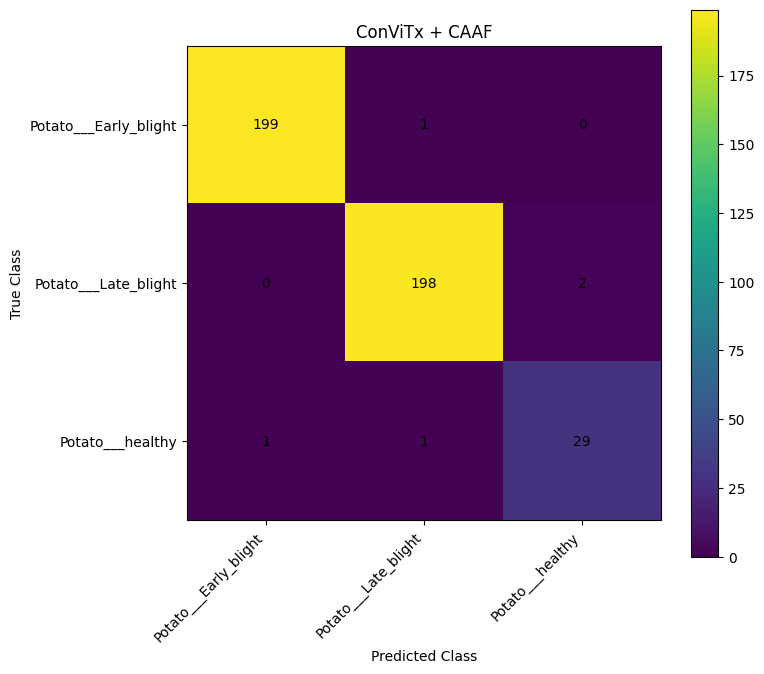


Saved:
/content/ConViTx_CAAF_Potato.keras


In [ ]:
# ============================================================
# ConViTx + CAAF - POTATO DISEASE CLASSIFICATION
#
# CNN (MobileNetV2) + SE
#              +
# ViT + SE
#              ↓
# CAAF
#              ↓
# Classifier
#
# CAAF uses REAL MULTI-TOKEN CROSS ATTENTION
#
# Stratified 80:20 split
# Confusion Matrix
# Classification Report
# ============================================================

# ============================================================
# 1. IMPORTS
# ============================================================

import os
import zipfile
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)


# ============================================================
# 2. CONFIGURATION
# ============================================================

ZIP_PATH = "/content/Potato.zip"
EXTRACT_DIR = "/content/Potato"

IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 10

SEED = 42
LEARNING_RATE = 1e-4

AUTOTUNE = tf.data.AUTOTUNE

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


# ============================================================
# 3. EXTRACT
# ============================================================

if not os.path.exists(EXTRACT_DIR):

    print("Extracting Potato.zip...")

    with zipfile.ZipFile(
        ZIP_PATH,
        "r"
    ) as zip_ref:

        zip_ref.extractall(
            EXTRACT_DIR
        )

    print("Extraction completed.")

else:

    print("Dataset already extracted.")


# ============================================================
# 4. FIND DATASET
# ============================================================

REQUIRED_CLASSES = [
    "Potato___Early_blight",
    "Potato___Late_blight",
    "Potato___healthy"
]


def find_dataset_directory(root):

    for current_root, dirs, files in os.walk(root):

        if all(
            c in dirs
            for c in REQUIRED_CLASSES
        ):

            return current_root

    raise FileNotFoundError(
        "Could not find all 3 Potato classes."
    )


DATASET_DIR = find_dataset_directory(
    EXTRACT_DIR
)

print(
    "\nDataset directory:"
)

print(
    DATASET_DIR
)


# ============================================================
# 5. COLLECT IMAGES
# ============================================================

image_paths = []
labels = []


for class_index, class_name in enumerate(
    REQUIRED_CLASSES
):

    class_dir = os.path.join(
        DATASET_DIR,
        class_name
    )


    class_images = [

        os.path.join(
            class_dir,
            f
        )

        for f in os.listdir(
            class_dir
        )

        if f.lower().endswith(
            (
                ".jpg",
                ".jpeg",
                ".png",
                ".bmp"
            )
        )

    ]


    print(
        class_name,
        ":",
        len(class_images)
    )


    image_paths.extend(
        class_images
    )

    labels.extend(
        [class_index] * len(class_images)
    )


image_paths = np.array(
    image_paths
)

labels = np.array(
    labels
)


# ============================================================
# 6. STRATIFIED SPLIT
# ============================================================

train_paths, val_paths, train_labels, val_labels = (

    train_test_split(

        image_paths,

        labels,

        test_size=0.20,

        random_state=SEED,

        stratify=labels

    )

)


# ============================================================
# 7. DISTRIBUTION CHECK
# ============================================================

print(
    "\nTRAIN DISTRIBUTION"
)

for i, name in enumerate(
    REQUIRED_CLASSES
):

    print(
        name,
        ":",
        np.sum(
            train_labels == i
        )
    )


print(
    "\nVALIDATION DISTRIBUTION"
)

for i, name in enumerate(
    REQUIRED_CLASSES
):

    print(
        name,
        ":",
        np.sum(
            val_labels == i
        )
    )


if np.any(
    np.bincount(
        val_labels,
        minlength=3
    ) == 0
):

    raise ValueError(
        "Validation set contains zero samples "
        "for a class."
    )


print(
    "\n✓ ALL THREE CLASSES PRESENT"
)


# ============================================================
# 8. IMAGE LOADER
# ============================================================

def load_image(
    path,
    label
):

    image = tf.io.read_file(
        path
    )

    image = tf.image.decode_image(

        image,

        channels=3,

        expand_animations=False

    )

    image = tf.image.resize(

        image,

        (
            IMG_SIZE,
            IMG_SIZE
        )

    )

    image = tf.cast(
        image,
        tf.float32
    )

    label = tf.one_hot(
        label,
        depth=3
    )

    return image, label


# ============================================================
# 9. TRAIN DATASET
# ============================================================

train_ds = tf.data.Dataset.from_tensor_slices(

    (
        train_paths,
        train_labels
    )

)

train_ds = train_ds.shuffle(

    len(train_paths),

    seed=SEED

)

train_ds = train_ds.map(

    load_image,

    num_parallel_calls=AUTOTUNE

)

train_ds = train_ds.batch(
    BATCH_SIZE
)

train_ds = train_ds.prefetch(
    AUTOTUNE
)


# ============================================================
# 10. VALIDATION DATASET
# ============================================================

val_ds = tf.data.Dataset.from_tensor_slices(

    (
        val_paths,
        val_labels
    )

)

val_ds = val_ds.map(

    load_image,

    num_parallel_calls=AUTOTUNE

)

val_ds = val_ds.batch(
    BATCH_SIZE
)

val_ds = val_ds.prefetch(
    AUTOTUNE
)


CLASS_NAMES = REQUIRED_CLASSES
NUM_CLASSES = 3


# ============================================================
# 11. AUGMENTATION
# ============================================================

augmentation = keras.Sequential(

    [

        layers.RandomFlip(
            "horizontal"
        ),

        layers.RandomRotation(
            0.10
        ),

        layers.RandomZoom(
            0.10
        ),

        layers.RandomContrast(
            0.10
        )

    ],

    name="augmentation"
)


# ============================================================
# 12. SE BLOCK
# ============================================================

class SEBlock(
    layers.Layer
):

    def __init__(
        self,
        reduction=16,
        **kwargs
    ):

        super().__init__(
            **kwargs
        )

        self.reduction = reduction


    def build(
        self,
        input_shape
    ):

        channels = int(
            input_shape[-1]
        )

        reduced = max(
            channels // self.reduction,
            1
        )

        self.pool = (
            layers.GlobalAveragePooling2D()
        )

        self.fc1 = layers.Dense(
            reduced,
            activation="relu"
        )

        self.fc2 = layers.Dense(
            channels,
            activation="sigmoid"
        )

        self.reshape = layers.Reshape(
            (
                1,
                1,
                channels
            )
        )

        super().build(
            input_shape
        )


    def call(
        self,
        inputs
    ):

        x = self.pool(
            inputs
        )

        x = self.fc1(
            x
        )

        x = self.fc2(
            x
        )

        x = self.reshape(
            x
        )

        return inputs * x


# ============================================================
# 13. INPUT
# ============================================================

inputs = keras.Input(

    shape=(
        IMG_SIZE,
        IMG_SIZE,
        3
    )

)


# ============================================================
# 14. CNN BRANCH
# ============================================================

cnn_x = augmentation(
    inputs
)


cnn_x = (
    tf.keras.applications
    .mobilenet_v2
    .preprocess_input(
        cnn_x
    )
)


cnn_backbone = (

    tf.keras.applications
    .MobileNetV2(

        input_shape=(
            IMG_SIZE,
            IMG_SIZE,
            3
        ),

        include_top=False,

        weights="imagenet"

    )

)


cnn_backbone.trainable = True

for layer in cnn_backbone.layers[:-30]:

    layer.trainable = False


cnn_x = cnn_backbone(
    cnn_x
)


cnn_x = layers.Conv2D(

    256,

    1,

    padding="same",

    use_bias=False

)(cnn_x)


cnn_x = layers.BatchNormalization()(
    cnn_x
)


cnn_x = layers.Activation(
    "relu"
)(cnn_x)


cnn_x = SEBlock(
    reduction=16,
    name="CNN_SE"
)(cnn_x)


# ============================================================
# KEEP CNN SPATIAL TOKENS
# ============================================================

cnn_tokens = layers.Reshape(
    (
        -1,
        256
    ),
    name="CNN_Tokens"
)(cnn_x)


# ============================================================
# 15. ViT PATCHES
# ============================================================

class Patches(
    layers.Layer
):

    def __init__(
        self,
        patch_size=16,
        **kwargs
    ):

        super().__init__(
            **kwargs
        )

        self.patch_size = patch_size


    def call(
        self,
        images
    ):

        batch_size = tf.shape(
            images
        )[0]

        patches = tf.image.extract_patches(

            images=images,

            sizes=[
                1,
                self.patch_size,
                self.patch_size,
                1
            ],

            strides=[
                1,
                self.patch_size,
                self.patch_size,
                1
            ],

            rates=[
                1,
                1,
                1,
                1
            ],

            padding="VALID"

        )

        patch_dims = (
            patches.shape[-1]
        )

        return tf.reshape(

            patches,

            [
                batch_size,
                -1,
                patch_dims
            ]

        )


# ============================================================
# 16. PATCH ENCODER
# ============================================================

class PatchEncoder(
    layers.Layer
):

    def __init__(
        self,
        num_patches,
        projection_dim,
        **kwargs
    ):

        super().__init__(
            **kwargs
        )

        self.num_patches = (
            num_patches
        )

        self.projection = layers.Dense(
            projection_dim
        )

        self.position_embedding = (
            layers.Embedding(

                num_patches,

                projection_dim

            )
        )


    def call(
        self,
        patches
    ):

        positions = tf.range(
            self.num_patches
        )

        return (

            self.projection(
                patches
            )

            +

            self.position_embedding(
                positions
            )

        )


# ============================================================
# 17. ViT
# ============================================================

vit_x = augmentation(
    inputs
)


patches = Patches(
    16
)(vit_x)


vit_x = PatchEncoder(
    196,
    256
)(patches)


# ============================================================
# 18. TRANSFORMERS
# ============================================================

for i in range(4):

    x1 = layers.LayerNormalization(
        epsilon=1e-6
    )(vit_x)


    attention = (
        layers.MultiHeadAttention(

            num_heads=8,

            key_dim=32,

            dropout=0.1

        )(
            x1,
            x1
        )
    )


    vit_x = layers.Add()(
        [
            vit_x,
            attention
        ]
    )


    x2 = layers.LayerNormalization(
        epsilon=1e-6
    )(vit_x)


    x2 = layers.Dense(
        512,
        activation=tf.nn.gelu
    )(x2)


    x2 = layers.Dropout(
        0.1
    )(x2)


    x2 = layers.Dense(
        256
    )(x2)


    vit_x = layers.Add()(
        [
            vit_x,
            x2
        ]
    )


# ============================================================
# 19. ViT SE
# ============================================================

vit_x = layers.LayerNormalization(
    epsilon=1e-6
)(vit_x)


vit_x = layers.Reshape(
    (
        14,
        14,
        256
    )
)(vit_x)


vit_x = SEBlock(
    reduction=16,
    name="ViT_SE"
)(vit_x)


# ============================================================
# ViT TOKENS
# ============================================================

vit_tokens = layers.Reshape(

    (
        196,
        256
    ),

    name="ViT_Tokens"

)(vit_x)


# ============================================================
# 20. CAAF
# ============================================================

class CAAF(
    layers.Layer
):

    def __init__(
        self,
        projection_dim=256,
        num_heads=8,
        dropout=0.1,
        **kwargs
    ):

        super().__init__(
            **kwargs
        )


        self.cnn_norm = (
            layers.LayerNormalization(
                epsilon=1e-6
            )
        )


        self.vit_norm = (
            layers.LayerNormalization(
                epsilon=1e-6
            )
        )


        # CNN queries ViT

        self.cnn_to_vit = (
            layers.MultiHeadAttention(

                num_heads=num_heads,

                key_dim=(
                    projection_dim
                    // num_heads
                ),

                dropout=dropout

            )
        )


        # ViT queries CNN

        self.vit_to_cnn = (
            layers.MultiHeadAttention(

                num_heads=num_heads,

                key_dim=(
                    projection_dim
                    // num_heads
                ),

                dropout=dropout

            )
        )


        self.cnn_gate = layers.Dense(
            1
        )


        self.vit_gate = layers.Dense(
            1
        )


        self.output_projection = (
            layers.Dense(
                projection_dim,
                activation="relu"
            )
        )


    def call(
        self,
        inputs
    ):

        cnn_tokens, vit_tokens = inputs


        # ----------------------------------------------------
        # NORMALIZE
        # ----------------------------------------------------

        cnn_norm = self.cnn_norm(
            cnn_tokens
        )

        vit_norm = self.vit_norm(
            vit_tokens
        )


        # ----------------------------------------------------
        # CNN → ViT
        # ----------------------------------------------------

        cnn_attention = (

            self.cnn_to_vit(

                query=cnn_norm,

                key=vit_norm,

                value=vit_norm

            )

        )


        cnn_fused = (

            cnn_tokens

            +

            cnn_attention

        )


        # ----------------------------------------------------
        # ViT → CNN
        # ----------------------------------------------------

        vit_attention = (

            self.vit_to_cnn(

                query=vit_norm,

                key=cnn_norm,

                value=cnn_norm

            )

        )


        vit_fused = (

            vit_tokens

            +

            vit_attention

        )


        # ----------------------------------------------------
        # GLOBAL FEATURES
        # ----------------------------------------------------

        cnn_global = (
            tf.reduce_mean(
                cnn_fused,
                axis=1
            )
        )


        vit_global = (
            tf.reduce_mean(
                vit_fused,
                axis=1
            )
        )


        # ----------------------------------------------------
        # ADAPTIVE GATING
        # ----------------------------------------------------

        cnn_score = self.cnn_gate(
            cnn_global
        )


        vit_score = self.vit_gate(
            vit_global
        )


        scores = tf.concat(

            [
                cnn_score,
                vit_score
            ],

            axis=-1

        )


        weights = tf.nn.softmax(
            scores,
            axis=-1
        )


        cnn_weight = weights[
            :,
            0:1
        ]


        vit_weight = weights[
            :,
            1:2
        ]


        # ----------------------------------------------------
        # ADAPTIVE FUSION
        # ----------------------------------------------------

        fused = (

            cnn_weight
            * cnn_global

            +

            vit_weight
            * vit_global

        )


        fused = self.output_projection(
            fused
        )


        return fused


# ============================================================
# 21. APPLY CAAF
# ============================================================

fused = CAAF(

    projection_dim=256,

    num_heads=8,

    dropout=0.1,

    name="CAAF"

)(

    [
        cnn_tokens,
        vit_tokens
    ]

)


# ============================================================
# 22. CLASSIFIER
# ============================================================

x = layers.Dense(
    512,
    activation="relu"
)(fused)


x = layers.BatchNormalization()(
    x
)


x = layers.Dropout(
    0.4
)(x)


x = layers.Dense(
    256,
    activation="relu"
)(x)


x = layers.Dropout(
    0.3
)(x)


outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)


# ============================================================
# 23. MODEL
# ============================================================

model = keras.Model(

    inputs=inputs,

    outputs=outputs,

    name="ConViTx_CAAF_Potato"

)


model.summary()


# ============================================================
# 24. COMPILE
# ============================================================

model.compile(

    optimizer=keras.optimizers.Adam(

        learning_rate=LEARNING_RATE

    ),

    loss=keras.losses.CategoricalCrossentropy(

        label_smoothing=0.1

    ),

    metrics=[
        "accuracy"
    ]

)


# ============================================================
# 25. LR SCHEDULER
# ============================================================

def lr_schedule(
    epoch,
    lr
):

    if epoch < 10:

        return 1e-4

    elif epoch < 20:

        return 5e-5

    elif epoch < 35:

        return 2e-5

    return 1e-5


# ============================================================
# 26. CALLBACKS
# ============================================================

callbacks = [

    keras.callbacks.LearningRateScheduler(
        lr_schedule
    ),

    keras.callbacks.EarlyStopping(

        monitor="val_accuracy",

        patience=8,

        mode="max",

        restore_best_weights=True,

        verbose=1

    ),

    keras.callbacks.ModelCheckpoint(

        "/content/ConViTx_CAAF_Potato_best.keras",

        monitor="val_accuracy",

        mode="max",

        save_best_only=True,

        verbose=1

    )

]


# ============================================================
# 27. TRAIN
# ============================================================

print(
    "\nSTARTING ConViTx + CAAF"
)

history = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=EPOCHS,

    callbacks=callbacks

)


# ============================================================
# 28. EVALUATE
# ============================================================

loss, accuracy = model.evaluate(
    val_ds
)

print(
    "\nValidation Accuracy:",
    accuracy * 100,
    "%"
)


# ============================================================
# 29. CONFUSION MATRIX
# ============================================================

y_true = []
y_pred = []


for images, labels in val_ds:

    predictions = model.predict(

        images,

        verbose=0

    )


    y_true.extend(

        np.argmax(

            labels.numpy(),

            axis=1

        )

    )


    y_pred.extend(

        np.argmax(

            predictions,

            axis=1

        )

    )


y_true = np.array(
    y_true
)

y_pred = np.array(
    y_pred
)


cm = confusion_matrix(

    y_true,

    y_pred,

    labels=np.arange(
        NUM_CLASSES
    )

)


print(
    "\nCONFUSION MATRIX - ConViTx + CAAF"
)

print(cm)


print(
    "\nCLASSIFICATION REPORT"
)

print(

    classification_report(

        y_true,

        y_pred,

        labels=np.arange(
            NUM_CLASSES
        ),

        target_names=CLASS_NAMES,

        digits=4,

        zero_division=0

    )

)


# ============================================================
# 30. PLOT CONFUSION MATRIX
# ============================================================

plt.figure(
    figsize=(8, 7)
)

plt.imshow(
    cm,
    interpolation="nearest"
)

plt.title(
    "ConViTx + CAAF"
)

plt.colorbar()


plt.xticks(

    range(NUM_CLASSES),

    CLASS_NAMES,

    rotation=45,

    ha="right"

)


plt.yticks(

    range(NUM_CLASSES),

    CLASS_NAMES

)


for i in range(NUM_CLASSES):

    for j in range(NUM_CLASSES):

        plt.text(

            j,

            i,

            str(
                cm[i, j]
            ),

            ha="center",

            va="center"

        )


plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "True Class"
)

plt.tight_layout()

plt.show()


# ============================================================
# 31. SAVE
# ============================================================

model.save(
    "/content/ConViTx_CAAF_Potato.keras"
)

print(
    "\nSaved:"
)

print(
    "/content/ConViTx_CAAF_Potato.keras"
)